## Relatório PDI - Cores em Imagens e Vídeo
## Lab 5

**Aluno(s):** Gabriella Rodrigues, Nayara Amaral, Veronica Isobe \
**Data de publicação:** 27/03/2026 \
**Data de realização dos experimentos:** 22/03/2026

# 1. Introdução

O estudo das cores em imagens digitais é fundamental, pois a cor atua como um importante descritor visual, permitindo melhor interpretação, segmentação e análise de objetos em uma cena. Diferentemente das imagens em escala de cinza, as imagens coloridas oferecem maior riqueza de informação, aproximando-se mais da forma como o sistema visual humano percebe o mundo .

Neste laboratório, são realizadas atividades práticas utilizando Python e OpenCV, incluindo transformações entre espaços de cores, análise de luminosidade, aplicação de correção gama e manipulação de componentes cromáticos. Além disso, são propostos experimentos que evidenciam diferenças entre modelos de cor, especialmente no que diz respeito à percepção de brilho, separação de informação de cor e robustez a variações de iluminação .

Dessa forma, o laboratório busca consolidar o entendimento teórico por meio da experimentação prática, permitindo avaliar como diferentes representações de cor impactam diretamente o processamento e a interpretação de imagens digitais.


# 2. Procedimentos experimentais

### 2.1. Correção de Ponto Branco (White Point Correction - 4.1.11)

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


In [2]:
def white_point_correction(img, sourcewp, targetwp):
    # img escala [0, 1]
    corrected = img * (targetwp / sourcewp)
    return np.clip(corrected, 0, 1)

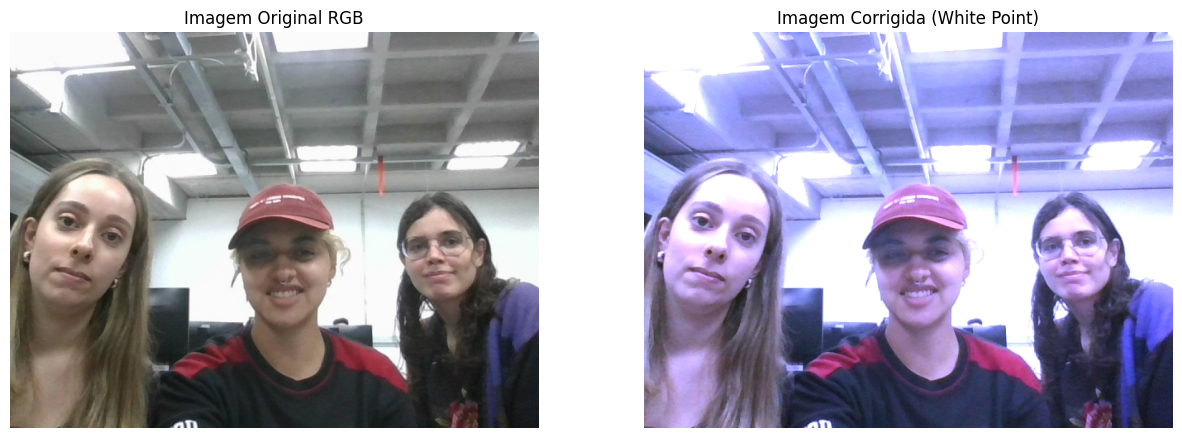

In [3]:
# imagem do grupo

img = cv2.imread('/content/drive/MyDrive/PDI-2026/Lab5/foto1.jpg')
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB) /255.0



# Simplificação: canais R, G, B
source_wp = np.array([0.8, 0.8, 0.5])
target_wp = np.array([1.0, 1.0, 1.0])
corrected_img = white_point_correction(img_rgb, source_wp, target_wp)

# Mostra a imagem corrigida
plt.figure(figsize=(15, 8))

plt.subplot(1, 2, 1) # 1 row, 2 columns, first plot
plt.imshow(img_rgb) # Display the original image (normalized)
plt.title('Imagem Original RGB')
plt.axis('off')

plt.subplot(1, 2, 2) # 1 row, 2 columns, second plot
plt.imshow(corrected_img)
plt.title('Imagem Corrigida (White Point)')
plt.axis('off')

plt.show()

### 2.2. Transformação XYZ para RGB e Correção Gama (4.1.12 e 4.1.13)

In [4]:
def xyz_to_rgb_gamma(xyz_img):
    # Matriz de conversão linear XYZ para RGB (exemplo para D65)
    matrix = np.array([[3.2406, -1.5372, -0.4986],
                       [-0.9689, 1.8758, 0.0415],
                       [0.0557, -0.2040, 1.0570]])

    rgb_linear = xyz_img @ matrix.T
    rgb_linear = np.clip(rgb_linear, 0, 1)

    # Correção Gama (4.1.13): sRGB standard
    # Aproximação: C = 1.055 * L^(1/2.4) - 0.055
    gamma_corrected = np.where(rgb_linear <= 0.0031308,
                               12.92 * rgb_linear,
                               1.055 * np.power(rgb_linear, 1/2.4) - 0.055)
    return gamma_corrected

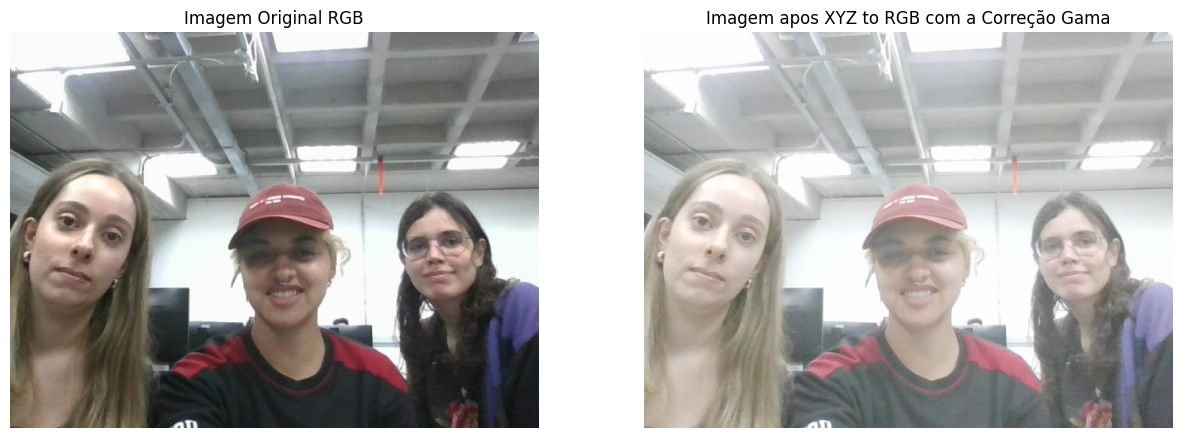

In [5]:
# imagem do grupo

img_rgb_float32 = img_rgb.astype(np.float32)
img_xyz = cv2.cvtColor(img_rgb_float32, cv2.COLOR_RGB2XYZ)

# Aplicando a funcao xyz_to_rgb_gamma :
gamma_corrected_xyz_to_rgb = xyz_to_rgb_gamma(img_xyz)

plt.figure(figsize=(15, 8))

plt.subplot(1, 2, 1)
plt.imshow(img_rgb)
plt.title('Imagem Original RGB')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(gamma_corrected_xyz_to_rgb)
plt.title('Imagem apos XYZ to RGB com a Correção Gama')
plt.axis('off')

plt.show()

### 2.3. O Modelo CIELAB (4.1.14)

Tarefa: Utilize cv2.cvtColor(img, cv2.COLOR_BGR2Lab) e visualize os canais separadamente para identificar como a informação de brilho é isolada da cor.

In [ ]:
# Converter para CIELAB
lab_img = cv2.cvtColor(img, cv2.COLOR_BGR2Lab)

# Separar os canais L*, a* e b*
L = lab_img[:, :, 0]      # Luminosidade (0-255)
a = lab_img[:, :, 1]      # Verde-Vermelho (0-255, centro ~128)
b = lab_img[:, :, 2]      # Azul-Amarelo (0-255, centro ~128)

# Visualizar os canais separadamente
plt.figure(figsize=(16, 10))

# Canal L* (Luminosidade)
plt.subplot(2, 3, 1)
plt.imshow(L, cmap='gray')
plt.title('Canal L* (Luminosidade)\n0 = Preto, 255 = Branco', fontsize=12)
plt.colorbar()
plt.axis('off')

# Canal a* (Verde-Vermelho)
plt.subplot(2, 3, 2)
plt.imshow(a, cmap='RdYlGn_r')
plt.title('Canal a* (Verde-Vermelho)\n0 = Verde, 128 = Neutro, 255 = Vermelho', fontsize=12)
plt.colorbar()
plt.axis('off')

# Canal b* (Azul-Amarelo)
plt.subplot(2, 3, 3)
plt.imshow(b, cmap='YlGnBu_r')
plt.title('Canal b* (Azul-Amarelo)\n0 = Amarelo, 128 = Neutro, 255 = Azul', fontsize=12)
plt.colorbar()
plt.axis('off')

# Imagem original para comparação
plt.subplot(2, 3, 4)
plt.imshow(img)
plt.title('Imagem Original (BGR)', fontsize=12)
plt.axis('off')

# Reconstrição apenas com L* (escala de cinza)
gray_from_lab = cv2.cvtColor(cv2.merge([L, np.ones_like(a)*128, np.ones_like(b)*128]),
                             cv2.COLOR_Lab2BGR)
plt.subplot(2, 3, 5)
plt.imshow(cv2.cvtColor(gray_from_lab, cv2.COLOR_BGR2RGB))
plt.title('Reconstrução com apenas L*\n(sem informação de cor)', fontsize=12)
plt.axis('off')

# Histograma do canal L*
plt.subplot(2, 3, 6)
plt.hist(L.ravel(), bins=256, color='black', alpha=0.7)
plt.title('Histograma do Canal L*\n(distribuição de luminosidade)', fontsize=12)
plt.xlabel('Valores de L*')
plt.ylabel('Frequência')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Análise dos valores
print("=== Análise dos Canais CIELAB ===")
print(f"Canal L* - Min: {L.min()}, Max: {L.max()}, Média: {L.mean():.1f}")
print(f"Canal a* - Min: {a.min()}, Max: {a.max()}, Média: {a.mean():.1f}")
print(f"Canal b* - Min: {b.min()}, Max: {b.max()}, Média: {b.mean():.1f}")
print("\nObservações:")
print("• L* varia de 0 (preto) a 255 (branco)")
print("• a* varia de 0 (verde) a 255 (vermelho), com 128 sendo neutro")
print("• b* varia de 0 (amarelo) a 255 (azul), com 128 sendo neutro")
print("• A separação permite trabalhar com brilho independente das cores!")

### 2.4. Cores Dependentes de Câmera: HSV e sRGB (4.2.3)

In [ ]:
def segmentar_por_cor(img_bgr):
    # 1. Converter para HSV
    hsv = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2HSV)

    # 2. Definir o intervalo da cor desejada (Exemplo: Verde)
    # No OpenCV: H vai de 0 a 179, S e V de 0 a 255
    verde_baixo = np.array([35, 50, 50])
    verde_alto = np.array([85, 255, 255])

    # 3. Criar uma máscara binária
    mask = cv2.inRange(hsv, verde_baixo, verde_alto)

    # 4. Aplicar a máscara na imagem original
    resultado = cv2.bitwise_and(img_bgr, img_bgr, mask=mask)

    return mask, resultado

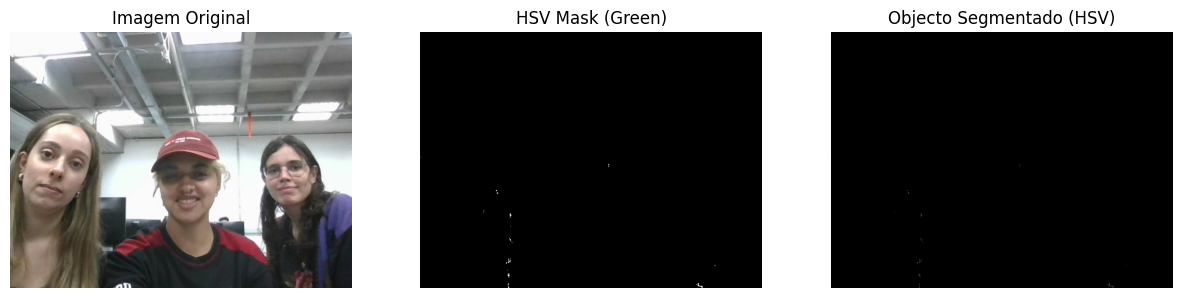

In [ ]:
if 'img' in locals() and img is not None:
    mask_hsv, segmented_object_hsv = segmentar_por_cor(img)

    plt.figure(figsize=(15, 5))

    plt.subplot(1, 3, 1)
    plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    plt.title('Imagem Original')
    plt.axis('off')

    plt.subplot(1, 3, 2)
    plt.imshow(mask_hsv, cmap='gray')
    plt.title('HSV Mask (Green)')
    plt.axis('off')

    plt.subplot(1, 3, 3)
    plt.imshow(cv2.cvtColor(segmented_object_hsv, cv2.COLOR_BGR2RGB))
    plt.title('Objecto Segmentado (HSV)')
    plt.axis('off')

    plt.show()
else:
    print("Error: 'img_bgr' is not defined. Please ensure the image is loaded first.")

### 2.5. Modelo $YCbCr$ (4.3.4)

In [ ]:
def rgb_to_ycbcr(rgb_img):
    # Coeficientes do livro (Seção 4.3.4)
    transform_mat = np.array([[0.299, 0.587, 0.114],
                              [-0.1687, -0.3313, 0.5],
                              [0.5, -0.4187, -0.0813]])
    # Ajuste de offset para Cb e Cr (normalmente 128 em 8 bits)
    ycbcr = rgb_img @ transform_mat.T
    ycbcr[:,:,1:] += 0.5
    return np.clip(ycbcr, 0, 1)

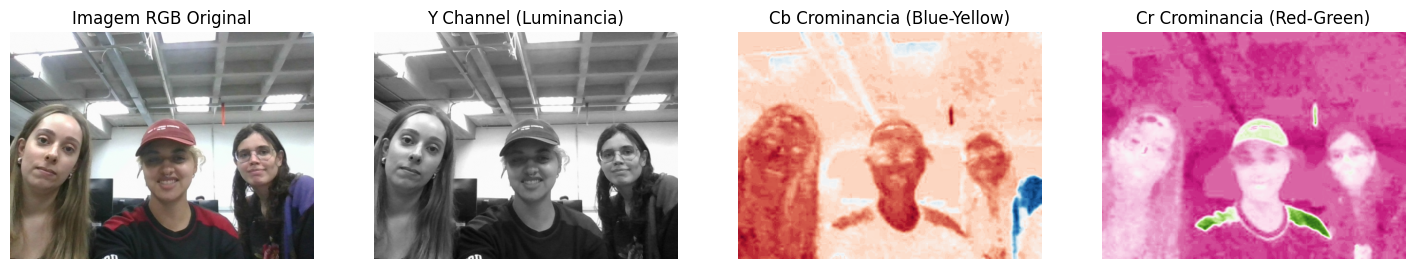

In [ ]:
if 'img_rgb' in locals() and img_rgb is not None:
    # Aplicar a função rgb_to_ycbcr
    ycbcr_img = rgb_to_ycbcr(img_rgb)

    # Separar os canais Y, Cb e Cr
    Y_channel = ycbcr_img[:, :, 0]
    Cb_channel = ycbcr_img[:, :, 1]
    Cr_channel = ycbcr_img[:, :, 2]

    # Plotar a imagem original e os canais separados
    plt.figure(figsize=(18, 5))

    plt.subplot(1, 4, 1)
    plt.imshow(img_rgb)
    plt.title('Imagem RGB Original')
    plt.axis('off')

    plt.subplot(1, 4, 2)
    plt.imshow(Y_channel, cmap='gray')
    plt.title('Y Channel (Luminancia)')
    plt.axis('off')

    plt.subplot(1, 4, 3)
    plt.imshow(Cb_channel, cmap='RdBu') # Red-Blue para Cb
    plt.title('Cb Crominancia (Blue-Yellow)')
    plt.axis('off')

    plt.subplot(1, 4, 4)
    plt.imshow(Cr_channel, cmap='PiYG') # Pink-Yellow-Green para Cr
    plt.title('Cr Crominancia (Red-Green)')
    plt.axis('off')

    plt.show()
else:
    print("Erro: 'img_rgb' não está definida. Por favor, carregue a imagem RGB primeiro.")

## ELABORAÇÃO DE PROGRAMAS COM A WEBCAM:
 2.6  
 Elabore um programa para realizar continuamente sobre a imagem da WEBCAM as operações de correção de ponto branco, e a correção gama, mostrando na tela o resultado em tempo real, permitindo ao operador escolher a visualização da imagem original, correção ponto branco, ou correção gama, ou ambas. Grave um video demonstrativo com os integrantes do grupo.

In [ ]:
# Função: Correção de ponto branco (Gray World)
def white_balance(img):
    img = img.astype(np.float32)

    avg_b = np.mean(img[:, :, 0])
    avg_g = np.mean(img[:, :, 1])
    avg_r = np.mean(img[:, :, 2])

    avg_gray = (avg_b + avg_g + avg_r) / 3

    img[:, :, 0] *= avg_gray / avg_b
    img[:, :, 1] *= avg_gray / avg_g
    img[:, :, 2] *= avg_gray / avg_r

    img = np.clip(img, 0, 255)
    return img.astype(np.uint8)

# Função: Correção gama
def gamma_correction(img, gamma=2.2):
    img_norm = img / 255.0
    img_gamma = np.power(img_norm, 1/gamma)
    img_gamma = np.clip(img_gamma * 255, 0, 255)
    return img_gamma.astype(np.uint8)

# Inicializar webcam
cap = cv2.VideoCapture(0)

mode = "original"

print("Teclas:")
print("o - original")
print("w - white balance")
print("g - gamma")
print("b - ambos")
print("q - sair")

while True:
    ret, frame = cap.read()
    if not ret:
        break

    # Espelhar (opcional)
    frame = cv2.flip(frame, 1)

    output = frame.copy()

    # Aplicar modos
    if mode == "white":
        output = white_balance(frame)

    elif mode == "gamma":
        output = gamma_correction(frame)

    elif mode == "both":
        wb = white_balance(frame)
        output = gamma_correction(wb)

    # Mostrar na tela
    cv2.putText(output, f"Modo: {mode}", (10, 30),
                cv2.FONT_HERSHEY_SIMPLEX, 1, (0,255,0), 2)

    cv2.imshow("Webcam - PDI", output)

    key = cv2.waitKey(1) & 0xFF

    if key == ord('o'):
        mode = "original"
    elif key == ord('w'):
        mode = "white"
    elif key == ord('g'):
        mode = "gamma"
    elif key == ord('b'):
        mode = "both"
    elif key == ord('q'):
        break

# Finalizar
cap.release()
cv2.destroyAllWindows()

### 2.7
Elabore um programa para realizar continuamente sobre a imagem da WEBCAM a detecção de uma cor pelo método HSV, mostrando lado-a-lado na tela a imagem original, e a imagem somente com as partes detectadas. Grave um video demonstrativo com os integrantes do grupo.

In [ ]:
# Inicializar webcam
cap = cv2.VideoCapture(0)

print("Pressione 'q' para sair")

while True:
    ret, frame = cap.read()
    if not ret:
        break

    # Espelhar imagem
    frame = cv2.flip(frame, 1)

    # Converter para HSV
    hsv = cv2.cvtColor(frame, cv2.COLOR_BGR2HSV)

    # Definir intervalo de cor
    lower1 = np.array([0, 120, 70])
    upper1 = np.array([10, 255, 255])

    lower2 = np.array([170, 120, 70])
    upper2 = np.array([180, 255, 255])

    # Máscara para vermelho (2 intervalos)
    mask1 = cv2.inRange(hsv, lower1, upper1)
    mask2 = cv2.inRange(hsv, lower2, upper2)

    mask = mask1 + mask2

    # Aplicar máscara
    result = cv2.bitwise_and(frame, frame, mask=mask)

    # Converter máscara para 3 canais (pra mostrar bonito)
    mask_rgb = cv2.cvtColor(mask, cv2.COLOR_GRAY2BGR)

    # Juntar lado a lado
    combined = np.hstack((frame, result))

    # Texto na tela
    cv2.putText(combined, "Original", (50, 30),
                cv2.FONT_HERSHEY_SIMPLEX, 1, (0,255,0), 2)

    cv2.putText(combined, "Detectado (HSV)", (frame.shape[1] + 50, 30),
                cv2.FONT_HERSHEY_SIMPLEX, 1, (0,255,0), 2)

    # Mostrar
    cv2.imshow("Deteccao de Cor HSV", combined)

    # Sair
    if cv2.waitKey(1) & 0xFF == ord('q'):
        break

cap.release()
cv2.destroyAllWindows()

### 2.8 Exercícios Propostos

**Comparação de Luminosidade (L\* vs Y)** \
Y (YCbCr) → representa luminância usada em vídeo (mais técnica) \
L* (CIELAB) → representa luminosidade perceptualmente uniforme, mais próxima da visão humana

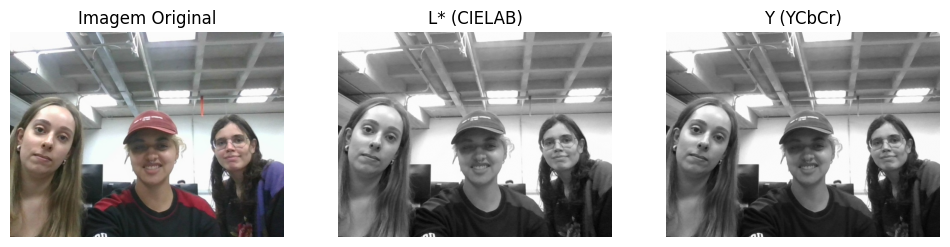

In [ ]:
# 4.1
img = cv2.imread('/content/drive/MyDrive/PDI-2026/Lab5/foto1.jpg')
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

# Converter para CIELAB
lab = cv2.cvtColor(img, cv2.COLOR_RGB2LAB)
L = lab[:, :, 0]   # canal L*

# Converter para YCbCr
ycbcr = cv2.cvtColor(img, cv2.COLOR_RGB2YCrCb)
Y = ycbcr[:, :, 0]   # canal Y

plt.figure(figsize=(12,6))

plt.subplot(1,3,1)
plt.title("Imagem Original")
plt.imshow(img)
plt.axis('off')

plt.subplot(1,3,2)
plt.title("L* (CIELAB)")
plt.imshow(L, cmap='gray')
plt.axis('off')

plt.subplot(1,3,3)
plt.title("Y (YCbCr)")
plt.imshow(Y, cmap='gray')
plt.axis('off')

plt.show()

**Efeito Gama**

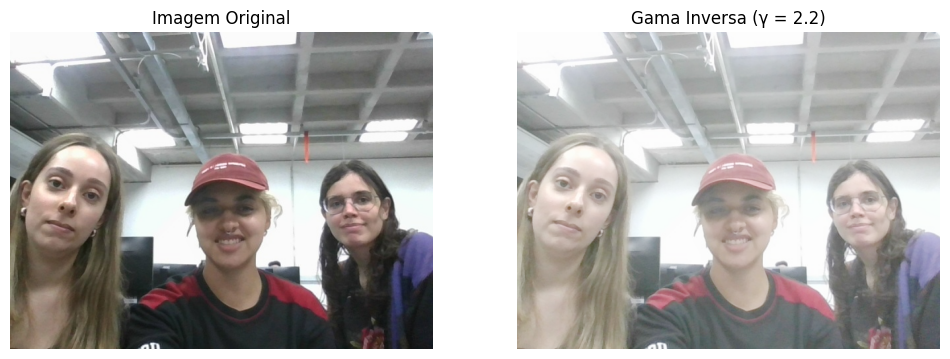

In [ ]:
# 4.2

# Normalizar para [0,1]
img_norm = img / 255.0

# Correção gama inversa (γ = 2.2)
gamma = 2.2
img_gamma = np.power(img_norm, 1/gamma)

# Voltar para [0,255]
img_gamma = (img_gamma * 255).astype(np.uint8)

plt.figure(figsize=(12,6))

plt.subplot(1,2,1)
plt.title("Imagem Original")
plt.imshow(img)
plt.axis('off')

plt.subplot(1,2,2)
plt.title("Gama Inversa (γ = 2.2)")
plt.imshow(img_gamma)
plt.axis('off')

plt.show()

**Filtro de cor**

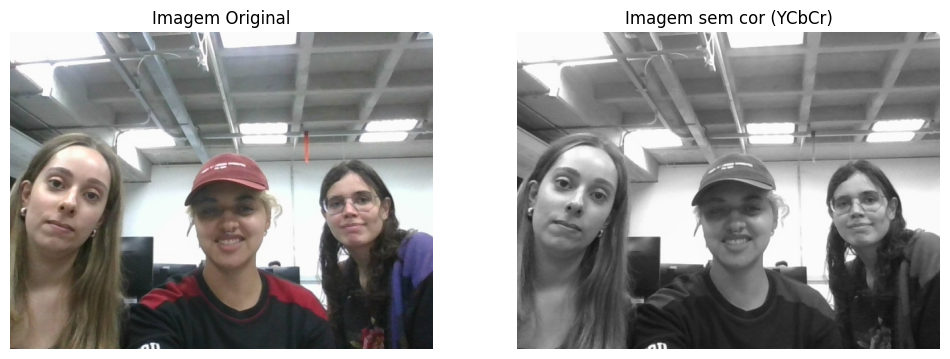

In [6]:
# 4.3 YCbCr → escala de cinza

import cv2
import numpy as np
import matplotlib.pyplot as plt

# Carregar imagem
img = cv2.imread('/content/drive/MyDrive/PDI-2026/Lab5/foto1.jpg')
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

# Converter para YCbCr
ycbcr = cv2.cvtColor(img, cv2.COLOR_RGB2YCrCb)

Y = ycbcr[:, :, 0]
Cr = ycbcr[:, :, 1]
Cb = ycbcr[:, :, 2]

# Zerar Cb e Cr (remover cor)
ycbcr_gray = ycbcr.copy()
ycbcr_gray[:, :, 1] = 128  # Cr neutro
ycbcr_gray[:, :, 2] = 128  # Cb neutro

# Converter de volta para RGB
img_gray = cv2.cvtColor(ycbcr_gray, cv2.COLOR_YCrCb2RGB)

plt.figure(figsize=(12,6))

plt.subplot(1,2,1)
plt.title("Imagem Original")
plt.imshow(img)
plt.axis('off')

plt.subplot(1,2,2)
plt.title("Imagem sem cor (YCbCr)")
plt.imshow(img_gray)
plt.axis('off')

plt.show()

# 3. Análise e Discussão

### Responder as Questões de Análise do Processamento de Cores

#### a)  Sobre  Ponto  Branco e Constância de Cor (Seção 4.1.11): Por que a correção de ponto branco é  considerada uma "transformação de adaptação cromática"?
A correção de ponto branco é chamada de transformação de adaptação cromática porque simula a capacidade do sistema visual humano de ajustar-se a diferentes fontes de luz (iluminantes) para manter a percepção das cores dos objetos constante, um fenômeno conhecido como constância de cor. Ela compensa matematicamente a cor da iluminação para garantir que objetos neutros sejam representados como brancos puros na imagem final.


#### b)  Espaços  Independentes  vs.  Dependentes  (Seção  4.1.12  e  4.2.3):  Qual  a  principal  diferença  prática  entre  o  espaço de cores CIE XYZ e o sRGB? Por que não exibimos imagens diretamente  em XYZ nos monitores comuns?
A principal diferença é que o CIE XYZ é um espaço independente de dispositivo, representando todas as cores visíveis pelo ser humano, enquanto o sRGB é dependente, sendo otimizado para o hardware de monitores e câmeras. Não exibimos imagens diretamente em XYZ porque os monitores comuns possuem um gamut (gama de cores) limitado e não conseguem reproduzir fisicamente toda a amplitude teórica de cores que o espaço XYZ define.

#### c)  A  Necessidade  da  Correção  Gama  (Seção  4.1.13):  Durante  a  aula,  aplicamos  a  correção gama Ccorrected=C(1/γ)linear  .  O  que  aconteceria  com  a  percepção  das  sombras  em  uma imagem se essa correção fosse omitida?
Se a correção gama fosse omitida, as sombras na imagem pareceriam excessivamente escuras e haveria uma perda significativa de detalhes perceptíveis nessas áreas[cite: 7, 8]. Isso ocorre porque os sensores das câmeras captam a luz de forma linear, enquanto a visão humana possui uma sensibilidade não linear, sendo muito mais eficiente em distinguir variações em baixas intensidades luminosas. Sem a aplicação do fator $(1/\gamma)$, os tons escuros não seriam expandidos para compensar essa característica da percepção humana e a resposta dos monitores, resultando em sombras "esmagadas".
#### d)  Percepção  Humana  e  o  Modelo  CIELAB  (Seção  4.1.14):  O  modelo L∗a∗b∗ é  frequentemente chamado  de  "perceptualmente  uniforme".  O  que  isso  significa  em  termos  de  distância  entre cores?
Ser "perceptualmente uniforme" significa que a distância euclidiana entre dois pontos de cor no espaço L∗a∗b∗ corresponde diretamente à diferença visual percebida pelo olho humano.
#### e)  Engenharia de Vídeo e YCbCr (Seção 4.3.4): No experimento de visualização, os canais  Cb  e  Cr  parecem  muito  mais  "suaves"  ou  "borrados"  que  o  canal   Y  .  Como  a  compressão  de  vídeo (como JPEG ou MPEG) utiliza essa característica para reduzir o tamanho dos arquivos?

Essa característica é explorada através de uma técnica chamada subamostragem de croma (chroma subsampling). Como o sistema visual humano possui uma resolução espacial muito maior para o brilho (luminância - Y) do que para a cor (crominância - Cb e Cr), os algoritmos de compressão como JPEG e MPEG reduzem a quantidade de dados nos canais de cor.

Ao amostrar os canais Cb e Cr em uma resolução inferior à do canal Y, é possível descartar uma grande quantidade de dados redundantes, reduzindo drasticamente o tamanho do arquivo sem que o olho humano perceba uma perda significativa na qualidade ou nitidez da imagem.
#### f) Representação Cilíndrica e Robustez (Seção 4.2.3): Ao realizar a segmentação de uma região com cor  uniforme,  por  que o canal H (Hue) do modelo HSV é frequentemente preferido em relação aos  canais  do  modelo  RGB  quando  a  imagem  possui  variações  de  iluminação  (sombras  e reflexos)?

O canal H (Hue) é preferido porque isola a "cor pura" das variações de brilho e intensidade. Enquanto no modelo RGB uma sombra altera os valores dos três canais simultaneamente, no HSV a iluminação afeta predominantemente os canais **S** e **V**, mantendo o canal **H** estável e facilitando a segmentação da mesma cor sob diferentes condições de luz.

# 4. Conclusão

A partir dos experimentos realizados, foi possível compreender a importância dos diferentes espaços de cor no processamento de imagens e como cada um deles atende a objetivos específicos. Observou-se que transformações como a correção de ponto branco e a correção gama são essenciais para alinhar a representação digital das imagens à percepção humana, garantindo maior fidelidade visual, especialmente em condições de iluminação variadas.

Além disso, ficou evidente a distinção entre espaços de cor independentes de dispositivo, como o CIE XYZ, e espaços dependentes, como o sRGB, destacando a necessidade de adaptação das cores para exibição em dispositivos reais. O modelo CIELAB mostrou-se particularmente relevante por sua uniformidade perceptual, permitindo uma análise mais consistente das diferenças de cor.

No contexto de compressão e representação eficiente, o modelo YCbCr demonstrou como a separação entre luminância e crominância pode ser explorada para reduzir dados sem perda significativa de qualidade visual. Por fim, verificou-se que modelos como HSV oferecem maior robustez em tarefas de segmentação, especialmente em cenários com variações de iluminação, devido à separação entre cor e intensidade.

Dessa forma, o laboratório evidenciou que a escolha do espaço de cor adequado é fundamental para o sucesso das técnicas de processamento digital de imagens, impactando diretamente na qualidade, eficiência e interpretação dos resultados obtidos.


# 5. Referências

* Ze-Nian Li , Mark S. Drew , and Jiangchuan Liu. Fundamentals of Multimedia . 2.ed. Springer, 2014. Chapter 4 “Color in Image and Video”, pp.81-114.
* Tutorial OpenCV e Python: Changing Colorspaces & Object Tracking
https://docs.opencv.org/3.4/df/d9d/tutorial_py_colorspaces.html
* Color spaces in OpenCV. Moukthika. April 29, 2025:
https://opencv.org/color-spaces-in-opencv/
* Color spaces in OpenCV (C++ / Python). Vikas Gupta. May 7, 2017:
https://learnopencv.com/color-spaces-in-opencv-cpp-python/